## Part 5: Lap Time Analysis
In this section, we analyze the qualifying lap times for each driver. This helps us identify the fastest laps and spot any significant time differences or outliers between drivers on the same track.

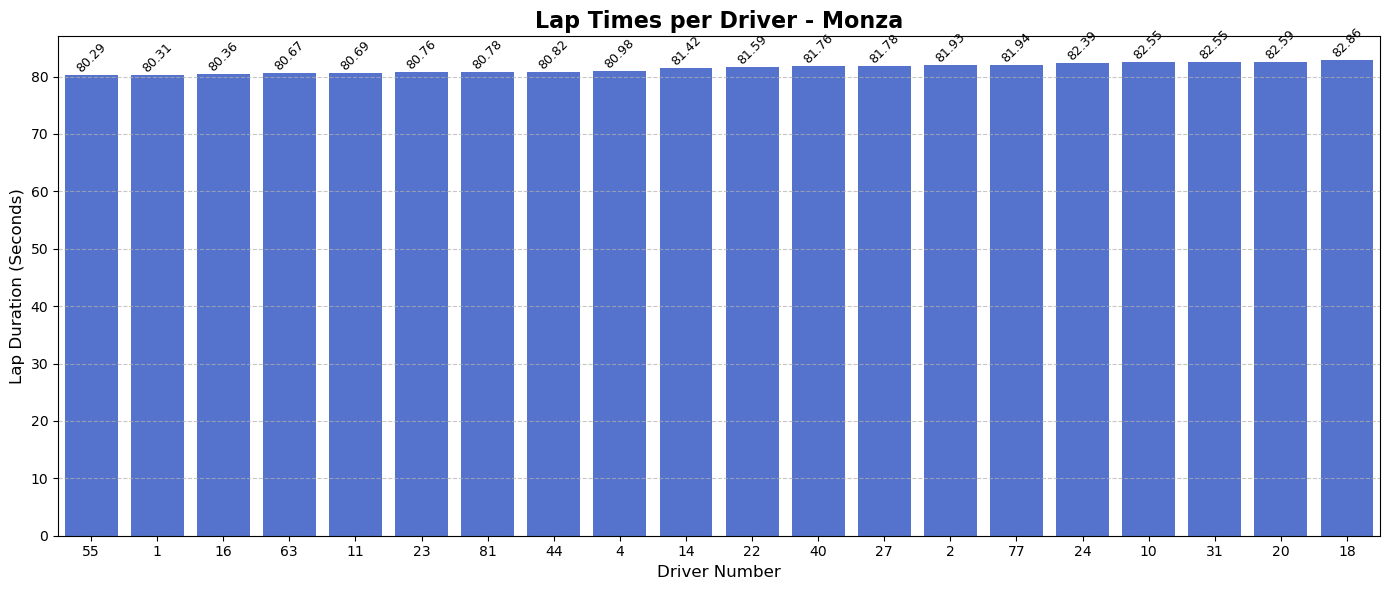

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_lap_times(track_name):
    # Set path to the data file
    file_path = '../processed_data/New_Qualifying_fastest_laps_telemetry.csv'
    
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return

    df = pd.read_csv(file_path)
    track_df = df[df['Track'] == track_name].copy()
    
    if track_df.empty:
        print(f"No data found for track: {track_name}")
        return
        
    # Get the lap duration for each driver
    driver_times = track_df.groupby('driver_number')['lap_duration'].first().reset_index()
    driver_times = driver_times.dropna(subset=['lap_duration'])
    
    # Sort times from fastest to slowest
    driver_times = driver_times.sort_values('lap_duration')
    
    # Create the plot
    plt.figure(figsize=(14, 6))
    sns.barplot(
        data=driver_times, 
        x='driver_number', 
        y='lap_duration', 
        order=driver_times['driver_number'], 
        color='royalblue'
    )
    
    plt.title(f'Lap Times per Driver - {track_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Driver Number', fontsize=12)
    plt.ylabel('Lap Duration (Seconds)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add exact time labels above the bars
    for index, row in enumerate(driver_times.itertuples()):
        plt.text(
            index, 
            row.lap_duration + 0.5, 
            f'{row.lap_duration:.2f}', 
            color='black', 
            ha="center", 
            fontsize=9,
            rotation=45
        )
        
    plt.tight_layout()
    plt.show()

# Test the function with Monza
plot_lap_times('Monza')

## Part 6: Raw Telemetry Outliers
Before feature engineering, we check the raw sensor data for physical limits and measurement errors. We use boxplots to find outliers in speed, throttle, braking, and RPM across the different tracks.

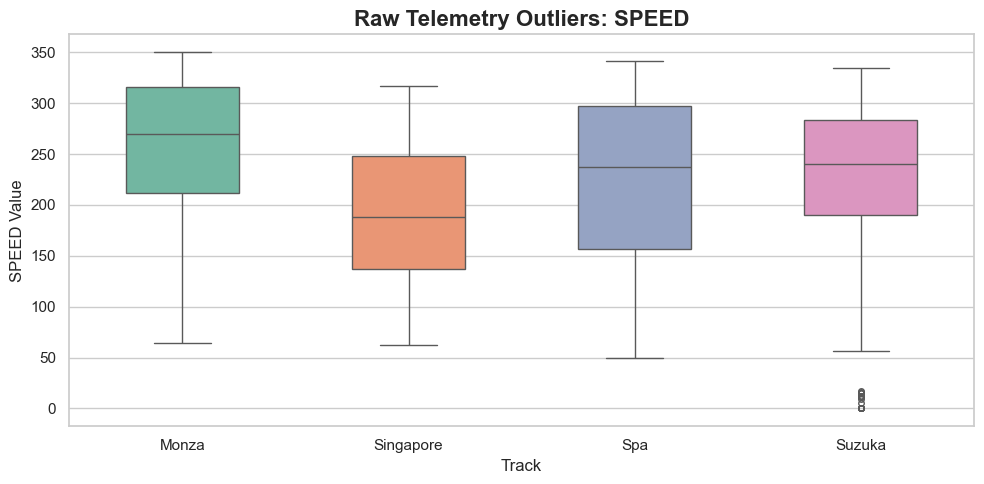

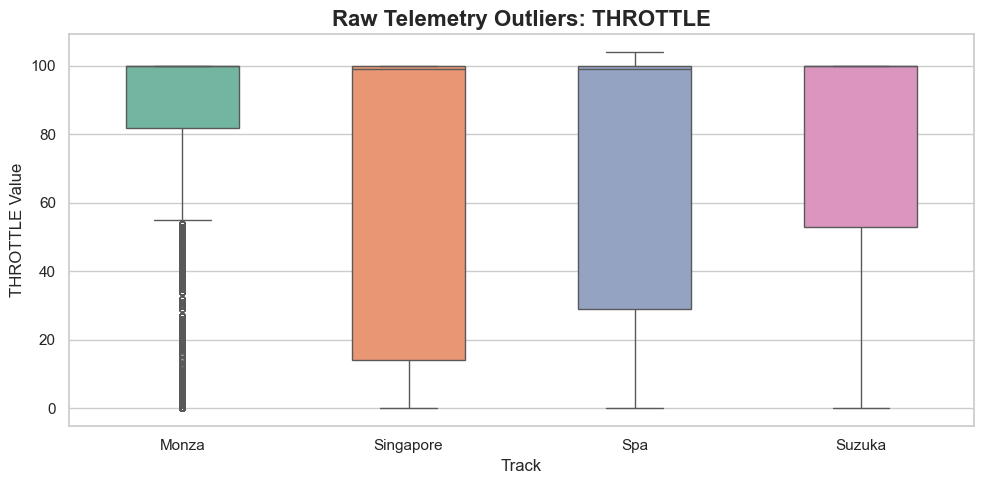

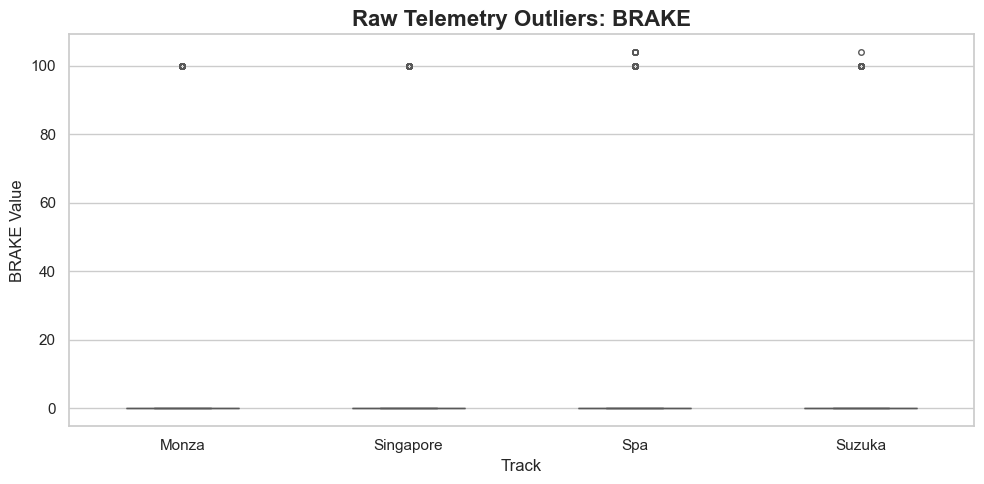

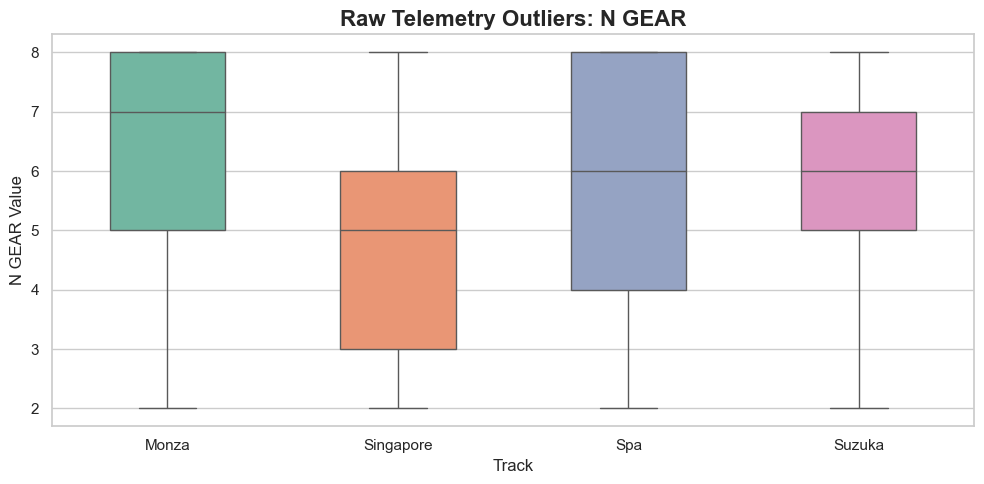

In [2]:
def generate_telemetry_outlier_plots():
    # Set path to the data file
    file_path = '../processed_data/New_Qualifying_fastest_laps_telemetry.csv'
    
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return

    df = pd.read_csv(file_path)
    
    # Convert column names to lowercase to avoid naming errors
    df.columns = df.columns.str.lower()
    
    # Rename 'ngear' to 'n_gear' if needed
    if 'ngear' in df.columns and 'n_gear' not in df.columns:
        df.rename(columns={'ngear': 'n_gear'}, inplace=True)

    has_track = 'track' in df.columns
    features_to_plot = ['rpm', 'speed', 'throttle', 'brake', 'n_gear']
    
    sns.set_theme(style="whitegrid")
    
    for feature in features_to_plot:
        if feature in df.columns:
            plt.figure(figsize=(10, 5))
            
            # Convert boolean brake to 0-100 scale for the plot
            if feature == 'brake' and df[feature].dtype == bool:
                plot_data = df[feature].astype(int) * 100
            else:
                plot_data = df[feature]
                
            # Draw the boxplot
            if has_track:
                sns.boxplot(x=df['track'], y=plot_data, hue=df['track'], palette="Set2", width=0.5, fliersize=4, legend=False)
                plt.xlabel('Track', fontsize=12)
            else:
                sns.boxplot(y=plot_data, color="royalblue", width=0.3, fliersize=4)
                plt.xlabel('All Tracks Combined', fontsize=12)
                
            clean_title = feature.replace('_', ' ').upper()
            plt.title(f'Raw Telemetry Outliers: {clean_title}', fontsize=16, fontweight='bold')
            plt.ylabel(f'{clean_title} Value', fontsize=12)
            
            plt.tight_layout()
            plt.show()

# Generate the plots
generate_telemetry_outlier_plots()

## Part 7: Final Feature Outliers (Clustering Matrix)
In this final step before applying the clustering algorithm, we visualize the outliers in our engineered features. We use boxplots combined with strip plots (jitter) to show both the statistical spread and the actual distribution of the individual corners for every track.

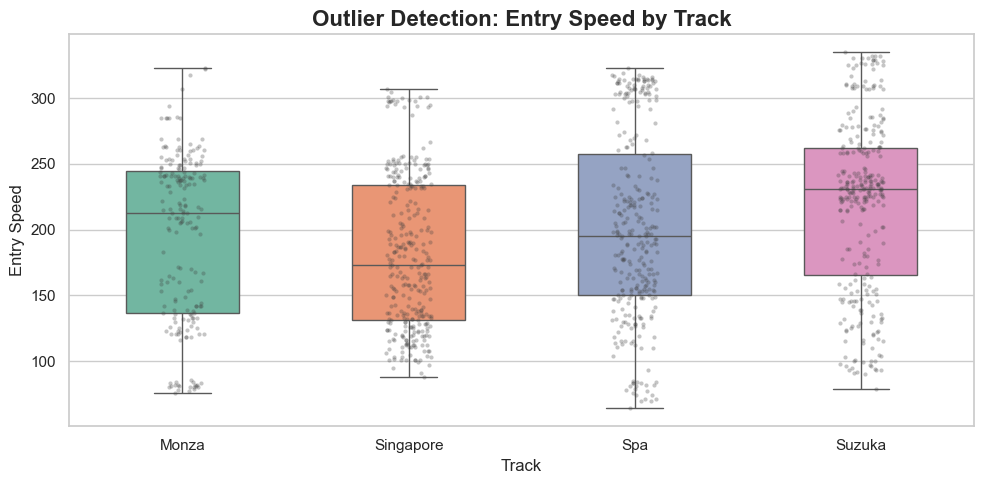

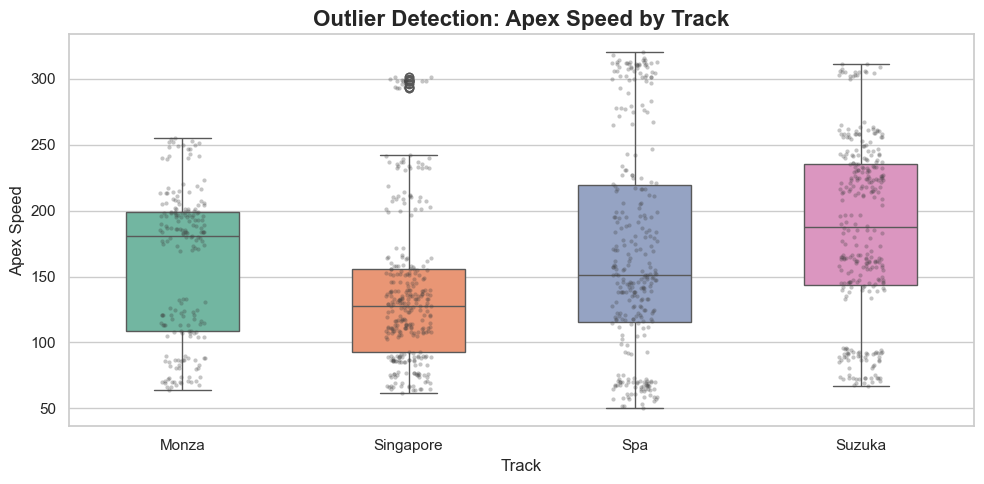

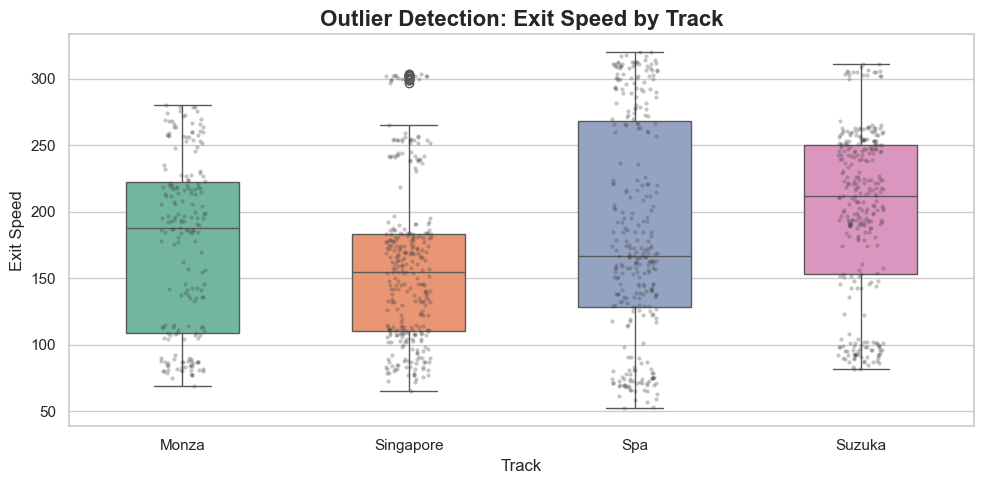

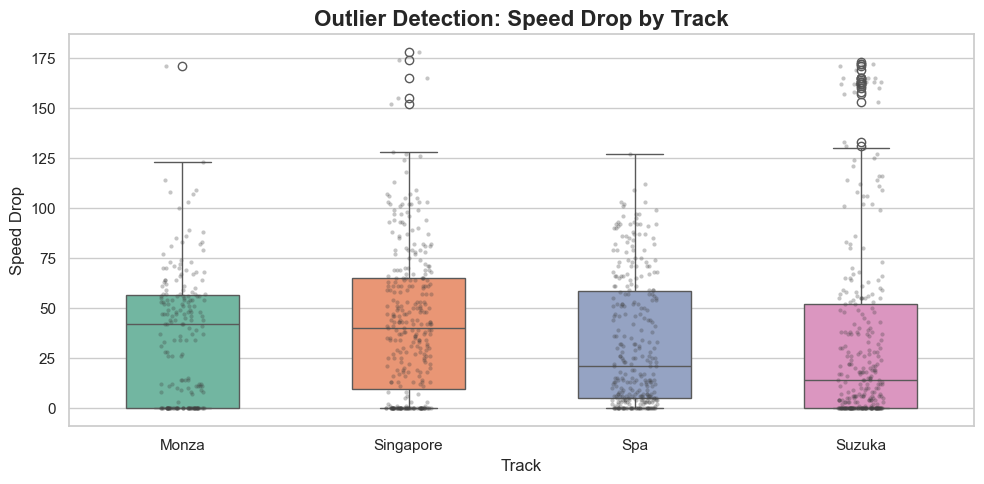

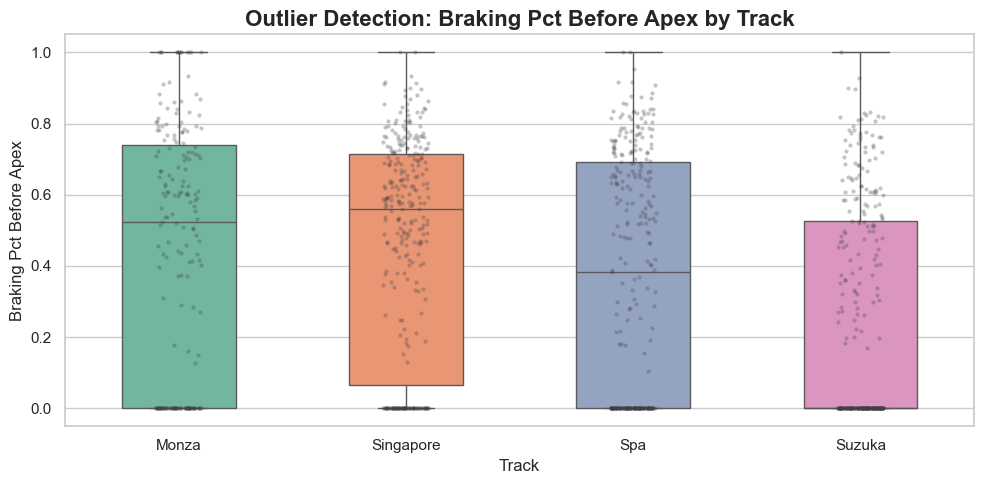

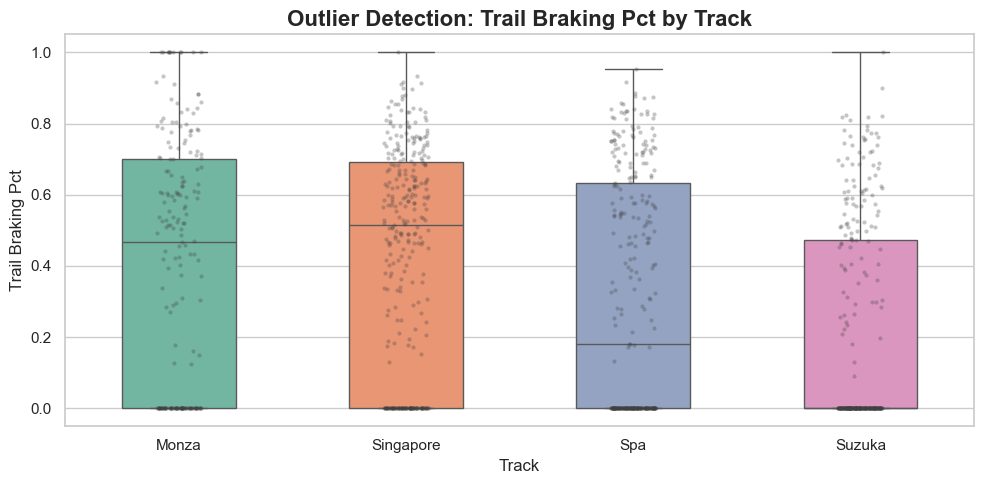

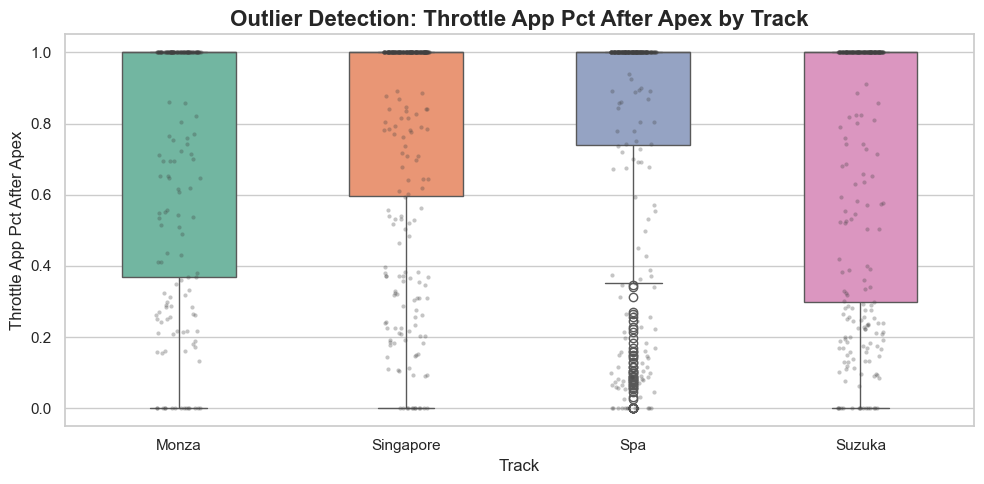

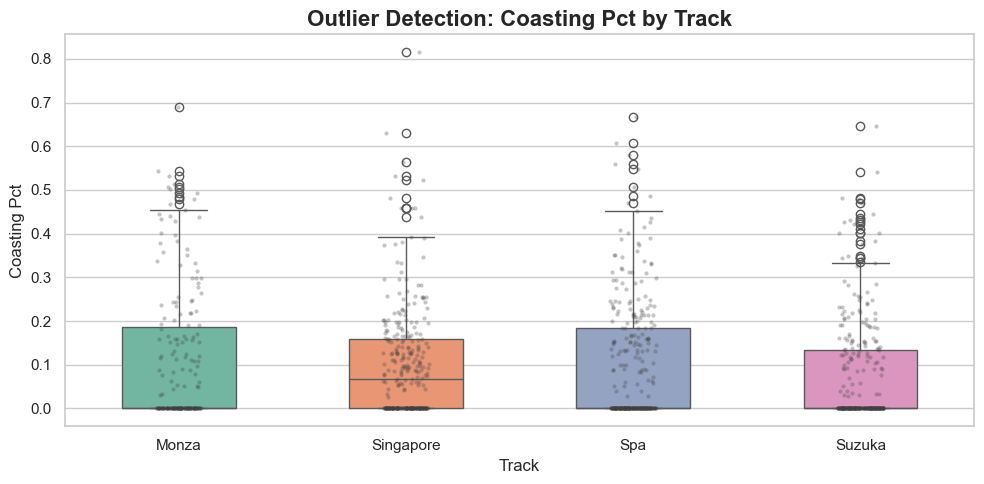

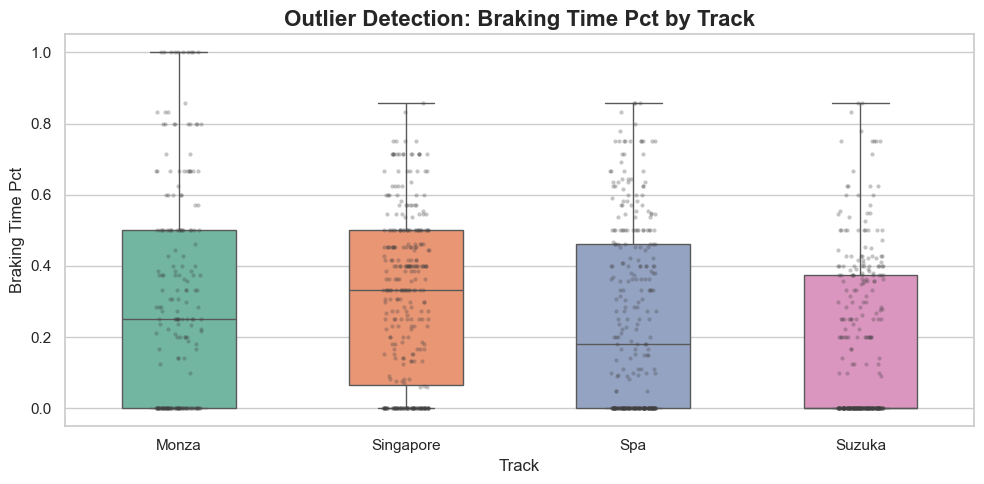

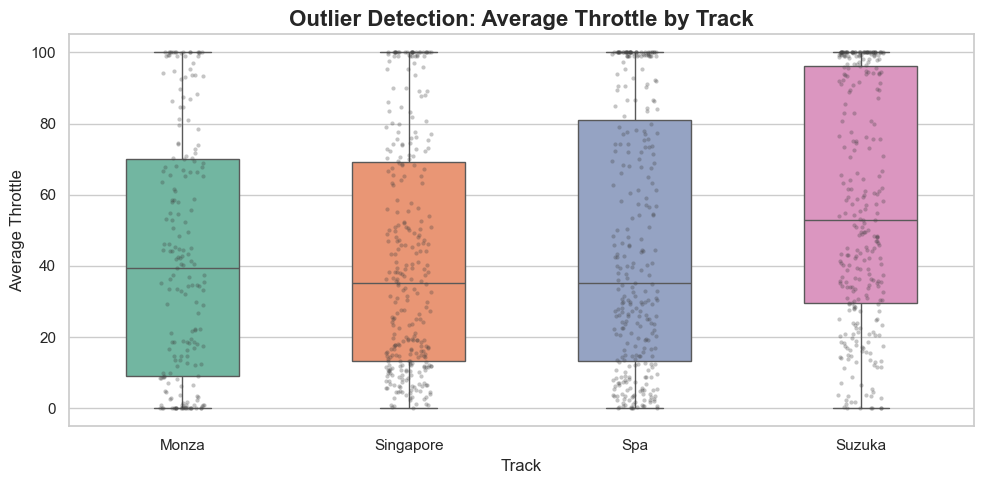

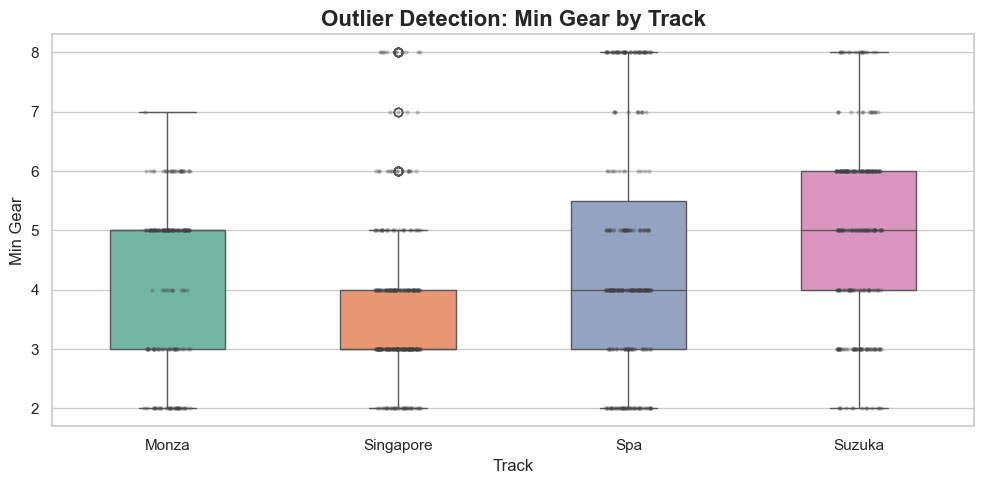

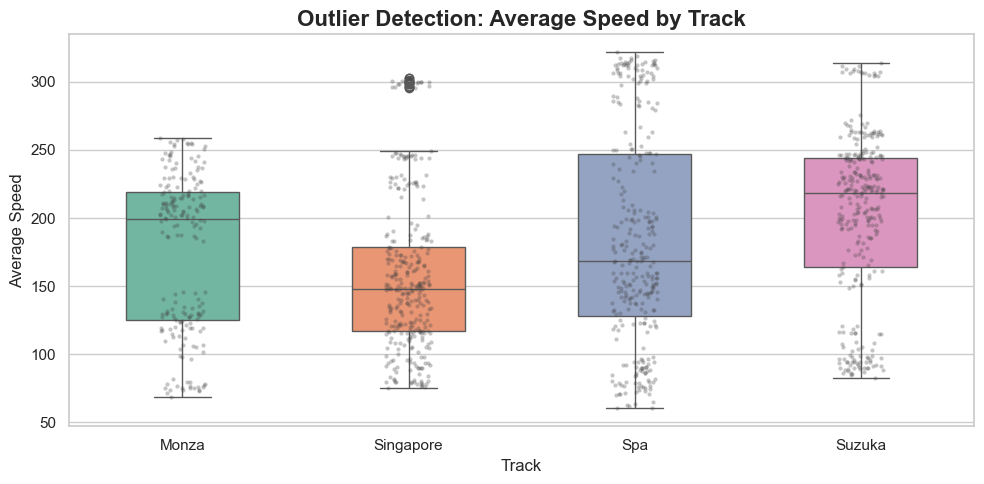

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def create_outlier_visualizations():
    # Set path to the final clustering matrix
    file_path = '../processed_data/Qualifying_final_clustering_matrix.csv'
    
    if not os.path.exists(file_path):
        print(f"Error: File not found at {file_path}")
        return

    df = pd.read_csv(file_path)

    # The engineered features we want to analyze
    features = [
        'entry_speed', 'apex_speed', 'exit_speed', 'speed_drop',
        'braking_pct_before_apex', 'trail_braking_pct', 
        'throttle_app_pct_after_apex', 'coasting_pct', 
        'braking_time_pct', 'average_throttle', 'min_gear', 'average_speed'
    ]
    
    available_features = [f for f in features if f in df.columns]
    
    if not available_features:
        print("Error: Could not find the specified columns. Check column names.")
        return

    sns.set_theme(style="whitegrid")
    
    # Generate a combined Boxplot + Stripplot for each feature
    for feature in available_features:
        plt.figure(figsize=(10, 5))
        
        # 1. Boxplot (shows the quartiles and statistical outliers)
        sns.boxplot(x='track', y=feature, data=df, hue='track', palette="Set2", width=0.5, fliersize=6, legend=False)
        
        # 2. Stripplot (shows the actual data points)
        sns.stripplot(x='track', y=feature, data=df, color=".25", alpha=0.3, size=3, jitter=True)
        
        # Styling
        clean_title = feature.replace("_", " ").title()
        plt.title(f'Outlier Detection: {clean_title} by Track', fontsize=16, fontweight='bold')
        plt.xlabel('Track', fontsize=12)
        plt.ylabel(clean_title, fontsize=12)
        
        plt.tight_layout()
        plt.show()

# Run the visualization function
create_outlier_visualizations()